# `solve_ivp` Simulation With Amplitude and Frequency Sweep

We solve the same internal-resonance model, but now using `scipy.integrate.solve_ivp`.

## Governing Equations (Expanded Form)

The two coupled second-order equations are

$$
\ddot{u}_1 + 2\varepsilon\mu_1\dot{u}_1 + \omega_1^2 u_1 = k_1 u_1 u_2 + \varepsilon f_1\cos(\Omega t),
$$

$$
\ddot{u}_2 + 2\varepsilon\mu_2\dot{u}_2 + \omega_2^2 u_2 = k_2 u_1^2 + \varepsilon^2 f_2\cos(\Omega t).
$$

For each sweep point, we vary both:
- excitation amplitude $f_2$
- excitation frequency ratio $r = \Omega/\omega_2$ (so $\Omega = r\,\omega_2$).

To integrate with `solve_ivp`, we use the first-order state

$$
\mathbf{y} = [u_1,\; v_1,\; u_2,\; v_2]^T,
\qquad v_1 = \dot{u}_1,\; v_2 = \dot{u}_2,
$$

with

$$
\dot{u}_1 = v_1,
$$

$$
\dot{v}_1 = -\omega_1^2 u_1 - 2\varepsilon\mu_1 v_1 + k_1 u_1 u_2 + \varepsilon f_1\cos(\Omega t),
$$

$$
\dot{u}_2 = v_2,
$$

$$
\dot{v}_2 = -\omega_2^2 u_2 - 2\varepsilon\mu_2 v_2 + k_2 u_1^2 + \varepsilon^2 f_2\cos(\Omega t).
$$

Steady-state RMS amplitudes are computed after transient removal:

$$
A_i(f_2, \Omega) = \sqrt{\frac{1}{T_s}\int_{t_{\mathrm{trans}}}^{t_{\mathrm{end}}} u_i^2(t) \, dt},\qquad i=1,2.
$$

In [21]:
import numpy as np
from scipy.optimize import fsolve
from scipy.integrate import solve_ivp
import sys
from pathlib import Path
import importlib

# add project root to Python path (highest priority)
project_root = Path.cwd().parents[2]
project_root_str = str(project_root)
if project_root_str not in sys.path:
    sys.path.insert(0, project_root_str)

import Modeling
import Modeling.models.single_piezo as single_piezo
importlib.reload(single_piezo)
PiezoBeamFRF = single_piezo.PiezoBeamFRF
beam = PiezoBeamFRF(conf='series')  # or 'parallel
print('Electromechanical coupling coefficient : ', beam.theta_r)

Electromechanical coupling coefficient :  [ 0.03916596 -0.13602836  0.22331952 -0.31286861]


In [22]:
# def describe_obj(name, obj, indent=0):
#     pad = '  ' * indent
#     if isinstance(obj, dict):
#         print(f"{pad}{name}: dict with {len(obj)} keys")
#         for k, v in obj.items():
#             describe_obj(str(k), v, indent + 1)
#     elif isinstance(obj, np.ndarray):
#         print(f"{pad}{name}: ndarray shape={obj.shape}, dtype={obj.dtype}")
#     else:
#         print(f"{pad}{name}: {type(obj).__name__} -> {obj}")

# for k in exp_data.keys():
#     val = exp_data[k]
#     # print(f"\nTop-level item: {k}")
#     if isinstance(val, np.ndarray) and val.dtype == object and val.size == 1:
#         maybe_dict = val.item()
#         describe_obj(k, maybe_dict)
#     else:
#         describe_obj(k, val)

# plt.plot(exp_data['t'], exp_data['tip_signal'])

In [23]:
beam.C_p_eq*1e9

49.27790262172285

## Experimental vs Model Overlay (Analyze Linear + piezo_beam_FRF)
This section loads one experimental `.npz` file from `synthetic_impedance/Exp`, computes the FRF with Welch averaging, and overlays it with the analytical model from `ROM1.py`.

In [24]:
import sys
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import welch, csd


def estimate_frf_welch(base_signal, tip_signal, fs, trial_dur=4, overlap_frac=0.1, nfft_mult=4, window="hann"):
    """Estimate FRF using Welch/CSD with H1/H2 and geometric mean Hv."""
    nperseg = int(trial_dur * fs)
    noverlap = int(nperseg * overlap_frac)
    nfft = nperseg * nfft_mult

    freq, Sx = welch(base_signal, fs=fs, window=window, nperseg=nperseg, noverlap=noverlap, nfft=nfft)
    _, Sy = welch(tip_signal, fs=fs, window=window, nperseg=nperseg, noverlap=noverlap, nfft=nfft)
    _, Sxy = csd(base_signal, tip_signal, fs=fs, window=window, nperseg=nperseg, noverlap=noverlap, nfft=nfft)

    H1 = Sxy / Sx
    H2 = Sy / Sxy
    Hv = np.sqrt(H1 * H2)
    return freq, Hv, H1, H2


def _to_plain_dict(obj):
    """Convert loaded object to a plain dict when possible."""
    if isinstance(obj, dict):
        return obj
    if isinstance(obj, np.ndarray) and obj.dtype == object and obj.size == 1:
        maybe = obj.item()
        if isinstance(maybe, dict):
            return maybe
    return None


def load_experimental_dataset(data_path, name):
    """Load .npz or .mat experimental file with a unified result format."""
    p = Path(data_path)
    if not p.is_file():
        return {"name": name, "status": "failed", "error": f"file not found: {p}"}

    try:
        if p.suffix.lower() == ".npz":
            with np.load(p, allow_pickle=True) as data:
                if "arr_0" in data.files:
                    arr0_dict = _to_plain_dict(data["arr_0"] )
                    raw = arr0_dict if arr0_dict is not None else {k: data[k] for k in data.files}
                else:
                    raw = {k: data[k] for k in data.files}
        elif p.suffix.lower() == ".mat":
            from scipy.io import loadmat
            mat_data = loadmat(p)
            raw = {k: v for k, v in mat_data.items() if not k.startswith("__")}
        else:
            return {"name": name, "status": "failed", "error": f"unsupported file type: {p.suffix}"}

        return {"name": name, "status": "loaded", "path": p, "raw": raw}
    except Exception as e:
        return {"name": name, "status": "failed", "error": str(e)}


def extract_frf_from_dataset(d):
    """Return freq and FRF magnitude from either precomputed FRF fields or raw signals."""
    # Case 1: precomputed FRF exists in file.
    if "freq" in d:
        freq = np.asarray(d["freq"]).squeeze()
        for key in ["frf_mag", "frf_data", "FRF", "magnitude", "H_exp", "Hv"]:
            if key in d:
                frf = np.asarray(d[key]).squeeze()
                return freq, np.abs(frf), None, None

    # Case 2: raw time series; compute FRF via Welch.
    fs_key = "Fs" if "Fs" in d else ("fs" if "fs" in d else None)
    base_key = "base_accel" if "base_accel" in d else ("base_signal" if "base_signal" in d else None)
    tip_key = "tip_signal" if "tip_signal" in d else ("tip_vel" if "tip_vel" in d else None)

    if fs_key is None or base_key is None or tip_key is None:
        missing = []
        if fs_key is None:
            missing.append("Fs/fs")
        if base_key is None:
            missing.append("base_accel/base_signal")
        if tip_key is None:
            missing.append("tip_signal/tip_vel")
        raise KeyError("missing keys: " + ", ".join(missing))

    fs = float(np.asarray(d[fs_key]).squeeze())
    freq, H_exp, H1, H2 = estimate_frf_welch(
        base_signal=np.asarray(d[base_key]).squeeze(),
        tip_signal=np.asarray(d[tip_key]).squeeze(),
        fs=fs,
        trial_dur=d.get('trial_dur', 2),
        overlap_frac=0.4,
        nfft_mult=4,
        window="hann",
    )
    return freq, np.abs(H_exp), H1, H2


# Experimental datasets: path and styling for each configuration (merged dictionary).
exp_datasets = {
    "SC": {
        "path": r"C:\Users\setemadi3\GaTech Dropbox\Seyednima Etemadi\Projects\synthetic_impedance\Exp\March2026\10\SC.npz",
        # 'path':r"C:\Users\setemadi3\GaTech Dropbox\Seyednima Etemadi\Projects\synthetic_impedance\Exp\dat_Dec\1_Negative_capacitance\SC.npz",
        "color": "blue", "linestyle": "-", "linewidth": 2
    },
    "OC": {
        "path": r"C:\Users\setemadi3\GaTech Dropbox\Seyednima Etemadi\Projects\synthetic_impedance\Exp\March2026\10\OC_001.npz",
        "color": "red", "linestyle": "-", "linewidth": 2
    },
    "shunt_LR_OB": {
        "path": r"C:\Users\setemadi3\GaTech Dropbox\Seyednima Etemadi\Projects\synthetic_impedance\Exp\March2026\10\shunt_LR_OB.npz",
        "color": "green", "linestyle": "-", "linewidth": 2
    },
    "shunt_negative cap.": {
        "path": r"C:\Users\setemadi3\GaTech Dropbox\Seyednima Etemadi\Projects\synthetic_impedance\Exp\March2026\10\shunt.npz",
        "color": "purple", "linestyle": "-", "linewidth": 2
    },
}
simulation_cases = {
    "SC_simu": {
        "K_p": 100000, "K_i": 0.0, "K_c": 0.0, "R_c": 1e4,
        "color": "blue", "linestyle": "--", "linewidth": 1.5
    },
    "OC_simu": {
        "K_p": 1e-5, "K_i": 0.0, "K_c": 0.0, "R_c": 1e4,
        "color": "red", "linestyle": "--", "linewidth": 1.5
    },
    "Shunt_simu": {
        "K_p": 0.067, "K_i": 970, "K_c": 0.0, "R_c": 1e4,
        "color": "green", "linestyle": "--", "linewidth": 1.5
    },
    "Negative capacitance ratio = -0.5": {
        "K_p": 1e-5, "K_i": 0.0, "K_c": 0.0, "R_c": 1e4,
        "color": "purple", "linestyle": "--", "linewidth": 1.5,
        "negative_capacitance_ratio": -0.5
    },
    "resistive ": {
        "K_p": 4, "K_i": 0.0, "K_c": 0.0, "R_c": 1e4,
        "color": "purple", "linestyle": "-",'marker':'.', "linewidth": 1.5,
    }
}

# Load all datasets.
exp_loaded = {}
for name, config in exp_datasets.items():
    exp_loaded[name] = load_experimental_dataset(config["path"], name)

print("Experimental datasets:")
for name, item in exp_loaded.items():
    if item["status"] == "loaded":
        print(f"  loaded: {name} -> {item['path']}")
    else:
        print(f"  failed: {name} -> {item.get('error', 'unknown error')}")

# Compute/get FRF for all successfully loaded files.
exp_frf_data = {}
for name, item in exp_loaded.items():
    if item["status"] != "loaded":
        continue

    d = item["raw"]
    try:
        freq, mag, H1, H2 = extract_frf_from_dataset(d)
        exp_frf_data[name] = {
            "freq": freq,
            "mag": mag,
            "H1": H1,
            "H2": H2,
        }
    except Exception as e:
        print(f"  failed FRF extraction: {name} -> {e}")

if not exp_frf_data:
    raise RuntimeError("No experimental dataset produced a plottable FRF.")


Experimental datasets:
  loaded: SC -> C:\Users\setemadi3\GaTech Dropbox\Seyednima Etemadi\Projects\synthetic_impedance\Exp\March2026\10\SC.npz
  loaded: OC -> C:\Users\setemadi3\GaTech Dropbox\Seyednima Etemadi\Projects\synthetic_impedance\Exp\March2026\10\OC_001.npz
  loaded: shunt_LR_OB -> C:\Users\setemadi3\GaTech Dropbox\Seyednima Etemadi\Projects\synthetic_impedance\Exp\March2026\10\shunt_LR_OB.npz
  loaded: shunt_negative cap. -> C:\Users\setemadi3\GaTech Dropbox\Seyednima Etemadi\Projects\synthetic_impedance\Exp\March2026\10\shunt.npz


  computed: SC_simu
  computed: OC_simu
  computed: Shunt_simu
  computed: Negative capacitance ratio = -0.5
  computed: resistive 


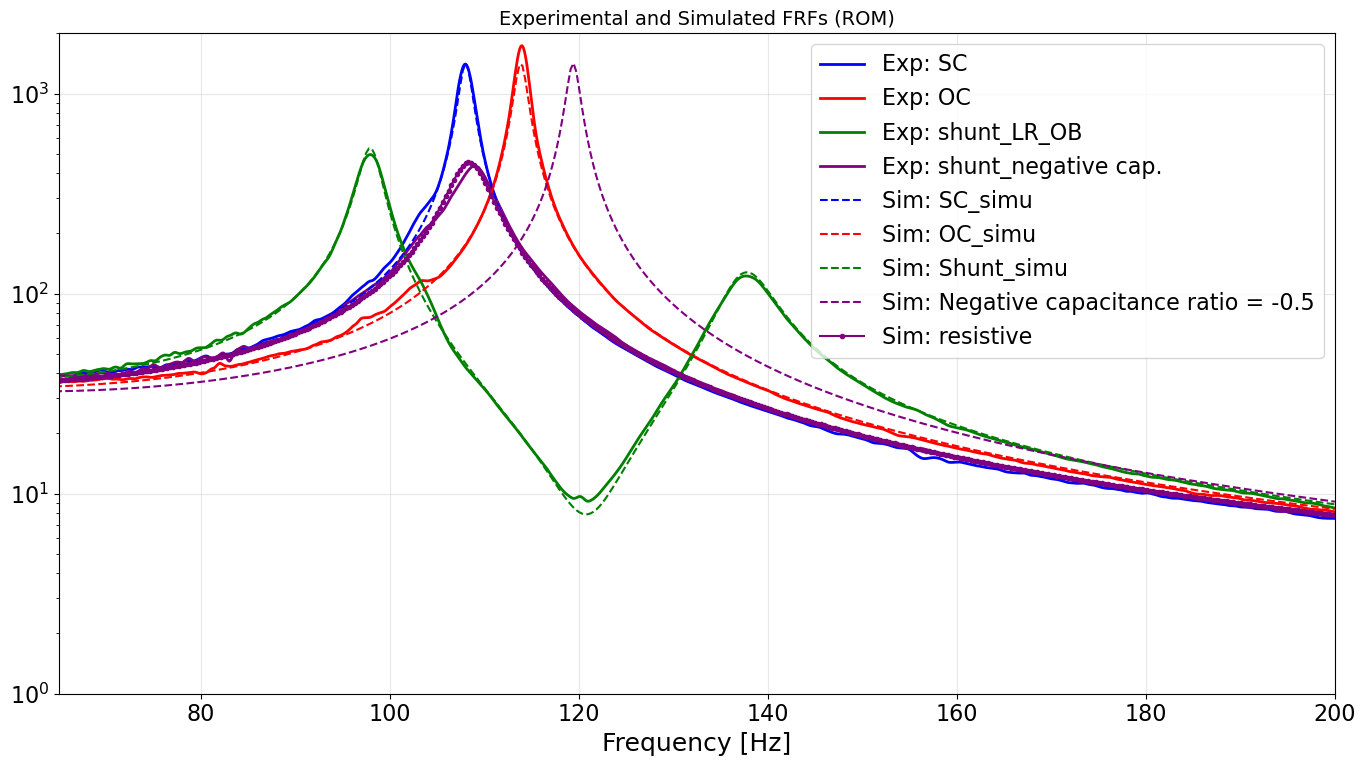


Plot complete. Experimental datasets: 4, Simulations: 5


In [25]:

# ============= ROM SETUP AND SIMULATION CASES =============
import importlib
from Modeling.models.beam_properties import PiezoBeamParams
import Modeling.models.ROM1 as rom1_module

importlib.reload(rom1_module)
ROM = rom1_module.ROM
L_b = 55e-3

params_rom = PiezoBeamParams(
    rho_p=7600,
    rho_s=8500,
    s11=14.5e-12,
    E_s=100e9,
    d31=-19.5e-11,
    eps_r=1700,
    b=31.75e-3,
    hp=0.275e-3,
    hs=0.128e-3,
    n_patches=1,
    w_p=L_b,
    omega_p=110 * 2 * np.pi,
    omega_q=200 * 2 * np.pi,
)
params_rom.L_b = L_b
params_rom.xL = np.array([0.0])
params_rom.xR = np.array([L_b])
no_modes = 1
rom = ROM(params=params_rom, N=no_modes, modal_damping_ratios=np.array([0.0065] * no_modes))

# Frequency sweep for ROM (same for all cases).
omega_rom = np.linspace(50, 200, 500)*2 * np.pi 

# Simulation cases: define control parameters and styling for each configuration (merged dictionary).


# Compute ROM responses for all simulation cases.
sim_frf_data = {}
for case_name, params in simulation_cases.items():
    try:
        ode_sys = rom.build_ode_system_base_excitation(
            a_base=lambda t: 1.0,
            j_exc=None,
            R_c=params["R_c"],
            K_p=params["K_p"],
            K_i=params["K_i"],
            K_c=params["K_c"],
            negative_capacitance_ratio=params.get("negative_capacitance_ratio", 0.0),
            base_accel_amp=1.0,
            freq_domain_amps=None,
        )
        
        freq_sim, rom_disp, rom_veloc = rom.frequency_response_fe3(
            ode_system=ode_sys,
            w=omega_rom,
            x_eval=np.linspace(0.0, params_rom.L_b, 20),
        )
        
        sim_frf_data[case_name] = {
            "freq": freq_sim,
            "mag": np.abs(rom_veloc[-1, :] 
             + 1/(1j*freq_sim*2*np.pi)
            ),
        }
        print(f"  computed: {case_name}")
    except Exception as e:
        print(f"  failed simulation: {case_name} -> {e}")

# ============= PLOTTING =============
plt.rcParams.update({
	"font.size": 9*2,
	"axes.labelsize": 9*2,
	"xtick.labelsize": 8*2,
	"ytick.labelsize": 8*2,
	"legend.fontsize": 8*2,
})
plt.figure(figsize=(14, 8))

# Plot all experimental FRFs.
for name, item in exp_frf_data.items():
    config = exp_datasets.get(name, {})
    style = {"color": config.get("color", "black"), "linestyle": config.get("linestyle", "-"), "linewidth": config.get("linewidth", 2), "marker": config.get("marker", None)}
    plt.semilogy(item["freq"], item["mag"], label=f"Exp: {name}",
                 color=style["color"], linestyle=style["linestyle"], linewidth=style["linewidth"], marker=style["marker"])

# Plot all simulation FRFs.
for case_name, item in sim_frf_data.items():
    params = simulation_cases.get(case_name, {})
    style = {"color": params.get("color", "gray"), "linestyle": params.get("linestyle", "--"), "linewidth": params.get("linewidth", 1.5),
             'marker': params.get("marker", None)}
    plt.semilogy(item["freq"], item["mag"]*1000*8, label=f"Sim: {case_name}",
                 color=style["color"], linestyle=style["linestyle"], linewidth=style["linewidth"], marker=style["marker"])

plt.xlim([65, 200])
plt.xlabel("Frequency [Hz]",)
# plt.ylabel("Magnitude", fontsize=12)
plt.ylim([1, 2e3])
plt.title("Experimental and Simulated FRFs (ROM)", fontsize=14)
plt.grid(True, alpha=0.3)
plt.legend( loc="best")
plt.tight_layout()
plt.show()

print(f"\nPlot complete. Experimental datasets: {len(exp_frf_data)}, Simulations: {len(sim_frf_data)}")

In [26]:
print('Electromechanical coupling= ', (rom.p.theta_mech * rom.Gamma)[0,0])
print('C_p_eq= ', rom.p.Cp_scalar*1e9)
print('First natural frequency (undamped) = ', rom.omega/(2*np.pi))


Electromechanical coupling=  0.08980169717447302
C_p_eq=  157.85320482758618
First natural frequency (undamped) =  [108.03116588]


In [27]:
rom

In [28]:
import time
import numpy as np
from numpy import pi
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

try:
    from joblib import Parallel, delayed
    HAS_JOBLIB = True
except ImportError:
    HAS_JOBLIB = False

# -----------------------------
# Parameters (same physical model)
# -----------------------------
eps = 0.05
sigma2 = 0.0
freq_scale = 2.0
w1 = 54*2*np.pi*freq_scale#rom.omega[0]
nonlin_scale = 100*10
w2 = 2 * w1 - eps * sigma2
mu1, mu2 = 0.02 * w1, 0.006 * w1
theta_mech = (rom.p.theta_mech * rom.Gamma)[0, 0]
zeta1, zeta2 = 0.0001, 0.0001
k1, k2 = nonlin_scale * 400 * w1**2, nonlin_scale * 400 * w1**2/theta_mech
f1 = 0.0

f2_values = np.linspace(0.05, 1, 15) *10/nonlin_scale*freq_scale**2
freq_ratio_values = np.linspace(0.8, 1.2, 20)
samples_per_period = 30
n_periods_total = 100
n_periods_transient = 70

omega_exc_values = freq_ratio_values * w2

rtol = 1e-7
atol = 1e-9
print("Electromechanical coupling= ", (rom.p.theta_mech * rom.Gamma)[0, 0])
print("C_p_eq= ", rom.p.Cp_scalar * 1e9)
print("First natural frequency (undamped) = ", rom.omega / (2 * np.pi))
print('2 mu1 = ', 2 * mu1 ,', ', '2 zeta1 w1= ', 2 * zeta1 * w1)
print('2 mu2= ', 2 * mu2, ', ', '2 zeta2 w2= ', 2 * zeta2 * w2)

def rhs(t, y, f2, omega_exc):
    u1, v1, u2, v2 = y
    F1 = eps * f1 * np.cos(omega_exc * t)
    F2 = f2 * np.cos(omega_exc * t)

    du1 = v1
    dv1 = -w1**2 * u1 - 2 *  mu1 * v1 + k1 * u1 * u2 + F1
    du2 = v2
    dv2 = -w2**2 * u2 - 2 *  mu2 * v2 + theta_mech*k2 * u1**2 + F2

    return np.array([du1, dv1, du2, dv2])

def run_case_ivp(f2, omega_exc, y0=None):
    dt = 2 * pi / (samples_per_period * omega_exc)
    t_end = n_periods_total * 2 * pi / omega_exc
    t_trans = n_periods_transient * 2 * pi / omega_exc

    n_steps = int(np.round(t_end / dt))
    t_eval = np.linspace(0.0, n_steps * dt, n_steps + 1)

    if y0 is None:
        y0 = np.array([0.0, 1e-3, 0.0, 0])

    t0 = time.perf_counter()
    sol = solve_ivp(
        rhs,
        [0.0, t_eval[-1]],
        y0,
        args=(f2, omega_exc),
        t_eval=t_eval,
        method="RK45",
        rtol=rtol,
        atol=atol,
    )
    runtime = time.perf_counter() - t0

    mask = sol.t >= t_trans
    u1 = sol.y[1]
    u2 = sol.y[2]

    a1_rms = np.sqrt(np.mean(u1[mask] ** 2))
    a2_rms = np.sqrt(np.mean(u2[mask] ** 2))

    return {
        "t": sol.t,
        "y": sol.y,
        "a1_rms": a1_rms,
        "a2_rms": a2_rms,
        "runtime_s": runtime,
    }

def run_frequency_row(i, omega_exc):
    """One frequency row: keep amplitude continuation sequential inside each worker."""
    y0_row = np.array([0.0, 1e-4, 0, 0])
    row_a1 = np.zeros(len(f2_values))
    row_a2 = np.zeros(len(f2_values))
    row_runtime = np.zeros(len(f2_values))

    for j, f2 in enumerate(f2_values):
        out = run_case_ivp(f2, omega_exc, y0=y0_row)
        row_a1[j] = out["a1_rms"]
        row_a2[j] = out["a2_rms"]
        row_runtime[j] = out["runtime_s"]
        y0_row = out["y"][:, -1].copy()

    return i, row_a1, row_a2, row_runtime

A1 = np.zeros((len(freq_ratio_values), len(f2_values)))
A2 = np.zeros((len(freq_ratio_values), len(f2_values)))
RUNTIME = np.zeros((len(freq_ratio_values), len(f2_values)))

# Parallelize over frequency points. Each worker handles one full amplitude sweep row.
n_jobs = -1  # use all cores
t_sweep_start = time.perf_counter()
if HAS_JOBLIB:
    results = Parallel(n_jobs=n_jobs, backend="loky", verbose=10)(
        delayed(run_frequency_row)(i, omega_exc)
        for i, omega_exc in enumerate(omega_exc_values)
    )
else:
    print("joblib not found, running sequential sweep.")
    results = [
        run_frequency_row(i, omega_exc)
        for i, omega_exc in enumerate(omega_exc_values)
    ]
t_sweep_total = time.perf_counter() - t_sweep_start

for i, row_a1, row_a2, row_runtime in results:
    A1[i, :] = row_a1
    A2[i, :] = row_a2
    RUNTIME[i, :] = row_runtime

print("Sweep completed (parallel over frequency rows when joblib is available).")
print(f"Grid size: {A1.shape[0]} frequency points x {A1.shape[1]} amplitude points")
print(f"Average runtime per case: {np.mean(RUNTIME):.3f} s")
print(f"Total wall time: {t_sweep_total:.3f} s")

Electromechanical coupling=  0.08980169717447302
C_p_eq=  157.85320482758618
First natural frequency (undamped) =  [108.03116588]
2 mu1 =  27.143360527015812 ,  2 zeta1 w1=  0.13571680263507907
2 mu2=  8.143008158104744 ,  2 zeta2 w2=  0.27143360527015814


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 16 concurrent workers.
[Parallel(n_jobs=-1)]: Done   4 out of  20 | elapsed:    8.1s remaining:   32.6s
[Parallel(n_jobs=-1)]: Done   7 out of  20 | elapsed:    8.3s remaining:   15.4s
[Parallel(n_jobs=-1)]: Done  10 out of  20 | elapsed:    8.5s remaining:    8.5s
[Parallel(n_jobs=-1)]: Done  13 out of  20 | elapsed:    9.2s remaining:    4.9s
[Parallel(n_jobs=-1)]: Done  16 out of  20 | elapsed:    9.5s remaining:    2.3s


Sweep completed (parallel over frequency rows when joblib is available).
Grid size: 20 frequency points x 15 amplitude points
Average runtime per case: 0.348 s
Total wall time: 10.790 s


[Parallel(n_jobs=-1)]: Done  20 out of  20 | elapsed:   10.7s finished


In [29]:
A2.shape


(20, 15)

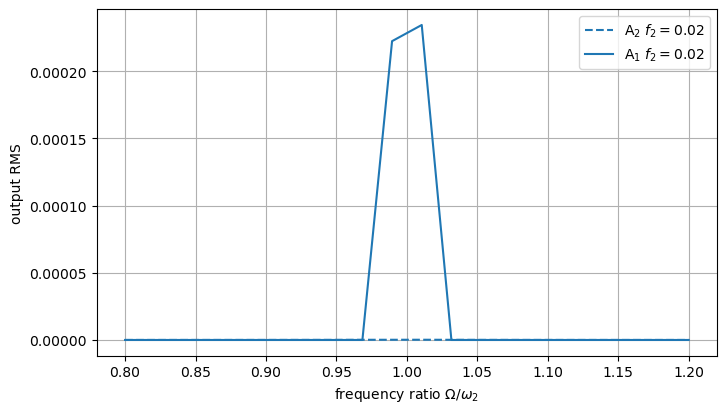

In [30]:
# fig, axs = plt.subplots(1, 3, figsize=(16, 4.5), constrained_layout=True)

# extent = [f2_values[0], f2_values[-1], freq_ratio_values[0], freq_ratio_values[-1]]

# im0 = axs[0].imshow(A1, origin="lower", aspect="auto", extent=extent)
# axs[0].set_title(r"$A_1$ RMS (solve_ivp)")
# axs[0].set_xlabel(r"forcing amplitude $f_2$")
# axs[0].set_ylabel(r"frequency ratio $\Omega/\omega_2$")
# fig.colorbar(im0, ax=axs[0], label="RMS")

# im1 = axs[1].imshow(A2, origin="lower", aspect="auto", extent=extent)
# axs[1].set_title(r"$A_2$ RMS (solve_ivp)")
# axs[1].set_xlabel(r"forcing amplitude $f_2$")
# axs[1].set_ylabel(r"frequency ratio $\Omega/\omega_2$")
# fig.colorbar(im1, ax=axs[1], label="RMS")

# im2 = axs[2].imshow(RUNTIME, origin="lower", aspect="auto", extent=extent)
# axs[2].set_title("Runtime per case [s] (solve_ivp)")
# axs[2].set_xlabel(r"forcing amplitude $f_2$")
# axs[2].set_ylabel(r"frequency ratio $\Omega/\omega_2$")
# fig.colorbar(im2, ax=axs[2], label="s")

# plt.show()
plt.rcdefaults()
pick_js = [0, len(f2_values) // 2, len(f2_values) - 1]
pick_js = [7]
plt.figure(figsize=(8, 4.5))
for j in pick_js:
    l1, = plt.plot(freq_ratio_values, A2[:, j], "--",  label=fr"A$_2$ $f_2={f2_values[j]:.2f}$")
    plt.plot(freq_ratio_values, A1[:, j], "-", color=l1.get_color(), label=fr"A$_1$ $f_2={f2_values[j]:.2f}$")
plt.xlabel(r"frequency ratio $\Omega/\omega_2$")
plt.ylabel(r"output RMS")
# plt.title(r"$A_2$ frequency response slices (solve_ivp)")
plt.grid(True)
plt.legend()
plt.show()


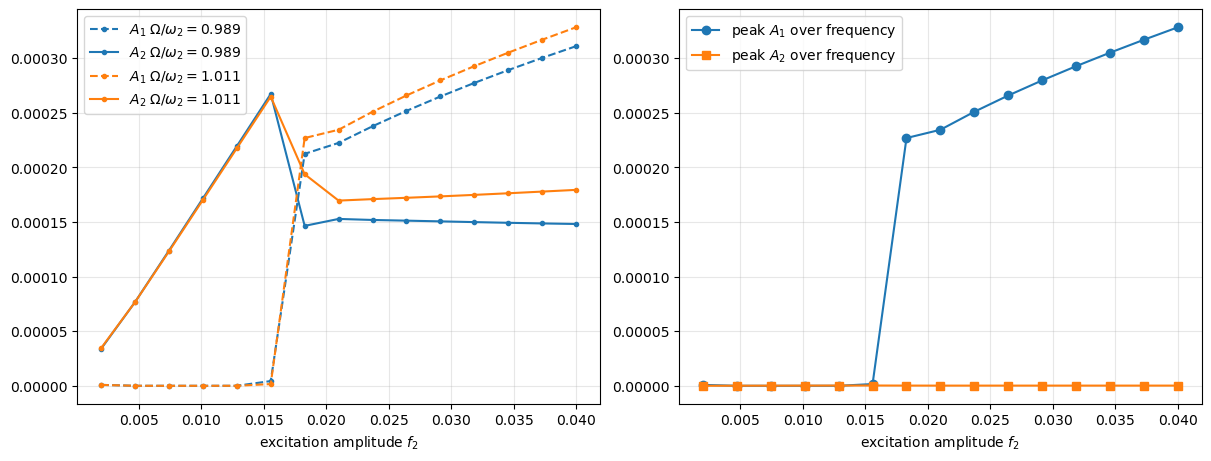

In [34]:

# ---- Amplitude vs excitation amplitude study ----
# 1) Fixed-frequency slices (near resonance).
target_ratios = [1.00, 1.02]
idxs = [int(np.argmin(np.abs(freq_ratio_values - r))) for r in target_ratios]

fig, axs = plt.subplots(1, 2, figsize=(12, 4.5), constrained_layout=True)
for idx in idxs:
    r = freq_ratio_values[idx]
    l1, = axs[0].plot(f2_values, A1[idx, :], '.--', label=fr"$A_1 \; \Omega/\omega_2={r:.3f}$")
    axs[0].plot(f2_values, A2[idx, :]*1000, '.-', color=l1.get_color(),label=fr"$A_2 \; \Omega/\omega_2={r:.3f}$")

axs[0].set_xlabel(r"excitation amplitude $f_2$")
axs[0].grid(True, alpha=0.3)
axs[0].legend()
idx = idxs[1]  # index for ratio closest to 1.00

axs[1].plot(f2_values, A1[idx, :], "-o", label=r"peak $A_1$ over frequency")
axs[1].plot(f2_values, A2[idx, :], "-s", label=r"peak $A_2$ over frequency")
axs[1].set_xlabel(r"excitation amplitude $f_2$")
axs[1].grid(True, alpha=0.3)
axs[1].legend()



In [32]:
rom.sigma_r * 30e-3*9.8
w1
rom.omega[0]

np.float64(678.7798341960588)